# 🚀 Space Defender - PRO MODE Fine-Tuning
## Fix Corner-Hiding Behavior

This notebook loads your existing ep10000 checkpoint and fine-tunes it with:
- ❌ Edge/corner penalty (no more hiding)
- ❌ Anti-camping penalty (must keep moving)
- ✅ Center position bonus
- ✅ Higher kill rewards (encourages aggression)
- ✅ Lower death penalty (encourages risk-taking)

**Time: ~30-45 minutes for 2000 episodes**

---
## 📌 Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

# =========================
# CONFIGURE YOUR PATHS HERE
# =========================
PROJECT_NAME = "Assignment 1 v1 A100 - Zhou Bojian"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# Where to load the checkpoint from
CHECKPOINT_PATH = f"{BASE_DIR}/finetune_promode_20260116_055054/models/best_avg_model.pth"

# Create output directory for fine-tuned model
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"{BASE_DIR}/finetune_promode_v3_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/videos", exist_ok=True)

print(f"📂 Loading checkpoint from: {CHECKPOINT_PATH}")
print(f"📂 Saving fine-tuned model to: {OUTPUT_DIR}")

# Verify checkpoint exists
if os.path.exists(CHECKPOINT_PATH):
    print("✅ best_avg_model found!")
else:
    print("❌ best_avg_model NOT found! Please check the path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading checkpoint from: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_promode_20260116_055054/models/best_avg_model.pth
📂 Saving fine-tuned model to: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_promode_v3_20260117_030936
✅ best_avg_model found!


---
## 📌 Step 2: Install Dependencies

In [ ]:
!pip install pygame -q
!apt-get install -y xvfb ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay imageio[ffmpeg] -q

import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import imageio

print(f"✅ All packages installed!")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ All packages installed!
PyTorch: 2.9.0+cu126 | CUDA: True
GPU: Tesla T4


---
## 📌 Step 3: Configuration

In [ ]:
class Config:
    # Game dimensions
    SCREEN_WIDTH = 600
    SCREEN_HEIGHT = 800

    # Player settings
    PLAYER_WIDTH = 50
    PLAYER_HEIGHT = 40
    PLAYER_SPEED = 8
    PLAYER_BULLET_SPEED = 12
    PLAYER_SHOOT_COOLDOWN = 15
    PLAYER_MAX_HEALTH = 3

    # Enemy settings
    ENEMY_WIDTH = 40
    ENEMY_HEIGHT = 35
    ENEMY_SPEED = 3
    ENEMY_BULLET_SPEED = 6
    ENEMY_SPAWN_RATE = 60
    MAX_ENEMIES = 8
    ENEMY_SHOOT_CHANCE = 0.02

    # Q-Learning hyperparameters (for fine-tuning)
    LEARNING_RATE = 0.00005
    DISCOUNT_FACTOR = 0.99
    EPSILON_START = 0.1       # Start with some exploration
    EPSILON_MIN = 0.01        # Go to slient noise
    EPSILON_DECAY = 0.9998     # Slower decay for fine-tuning
    BATCH_SIZE = 512
    MEMORY_SIZE = 100000
    TARGET_UPDATE = 100        # More frequent updates for fine-tuning

    # State: 22 features × 4 frames = 88
    STATE_SIZE = 88
    ACTION_SIZE = 6

print("✅ Config loaded (Fine-tuning mode)")
print(f"   Starting ε: {Config.EPSILON_START}")
print(f"   ε decay: {Config.EPSILON_DECAY}")

✅ Config loaded (Fine-tuning mode)
   Starting ε: 0.1
   ε decay: 0.9998


---
## 📌 Step 4: Game Objects

In [ ]:
class Player:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.PLAYER_WIDTH, Config.PLAYER_HEIGHT
        self.speed = Config.PLAYER_SPEED
        self.health = Config.PLAYER_MAX_HEALTH
        self.shoot_cooldown = 0
        self.score = 0
        self.alive = True

    def move(self, direction):
        self.x = max(0, min(self.x + direction * self.speed, Config.SCREEN_WIDTH - self.width))

    def update(self):
        if self.shoot_cooldown > 0: self.shoot_cooldown -= 1

    def can_shoot(self): return self.shoot_cooldown == 0

    def shoot(self):
        self.shoot_cooldown = Config.PLAYER_SHOOT_COOLDOWN
        return Bullet(self.x + self.width // 2 - 3, self.y - 15, -Config.PLAYER_BULLET_SPEED, True)

    def take_damage(self):
        self.health -= 1
        if self.health <= 0: self.alive = False


class Enemy:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.ENEMY_WIDTH, Config.ENEMY_HEIGHT
        self.speed = Config.ENEMY_SPEED + random.uniform(-1, 1)
        self.health, self.alive = 1, True
        self.direction = random.choice([-1, 0, 1])
        self.change_dir_timer = random.randint(30, 90)

    def update(self):
        self.y += self.speed
        self.x = max(0, min(self.x + self.direction * 2, Config.SCREEN_WIDTH - self.width))
        self.change_dir_timer -= 1
        if self.change_dir_timer <= 0:
            self.direction = random.choice([-1, 0, 1])
            self.change_dir_timer = random.randint(30, 90)
        if self.y > Config.SCREEN_HEIGHT: self.alive = False

    def should_shoot(self): return random.random() < Config.ENEMY_SHOOT_CHANCE

    def shoot(self):
        return Bullet(self.x + self.width // 2 - 3, self.y + self.height, Config.ENEMY_BULLET_SPEED, False)


class Bullet:
    def __init__(self, x, y, speed, is_player_bullet):
        self.x, self.y, self.speed = x, y, speed
        self.width, self.height = 6, 15
        self.is_player_bullet = is_player_bullet
        self.alive = True

    def update(self):
        self.y += self.speed
        if self.y < -self.height or self.y > Config.SCREEN_HEIGHT: self.alive = False

print("✅ Game objects defined!")

✅ Game objects defined!


---
## 📌 Step 5: Neural Network & Replay Memory

In [ ]:
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.network(x)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(args)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

print("✅ DQN and ReplayMemory defined!")

✅ DQN and ReplayMemory defined!


---
## 📌 Step 6: PRO MODE Environment (Anti-Corner-Hiding)

**Key changes from original:**
- Edge penalty: -0.3 per frame at corners
- Anti-camping: -0.5 if stationary too long
- Center bonus: +0.1 for staying in middle
- Higher kill reward: +50 (was +25)
- Lower death penalty: -200 (was -500)
- Shooting bonus: +0.2 to encourage aggression

In [ ]:
class SpaceDefenderEnv:
    """
    PRO MODE Environment - Fixes corner-hiding behavior
    """

    def __init__(self):
        self.state_buffer = deque(maxlen=4)
        self.last_x = None
        self.stationary_frames = 0
        self.reset()

    def reset(self):
        self.player = Player(
            Config.SCREEN_WIDTH // 2 - Config.PLAYER_WIDTH // 2,
            Config.SCREEN_HEIGHT - 100
        )
        self.enemies = []
        self.player_bullets = []
        self.enemy_bullets = []

        self.frame_count = 0
        self.spawn_timer = 0
        self.game_over = False
        self.enemies_destroyed = 0
        self.survival_time = 0

        # Anti-camping reset
        self.last_x = self.player.x
        self.stationary_frames = 0

        initial_frame = self._get_single_frame()
        for _ in range(4):
            self.state_buffer.append(initial_frame)

        return self._get_stacked_state()

    def _get_stacked_state(self):
        return np.concatenate(self.state_buffer)

    def _get_single_frame(self):
        state = []
        state.append(self.player.x / Config.SCREEN_WIDTH)
        state.append(1.0 if self.player.can_shoot() else 0.0)
        state.append(self.player.health / Config.PLAYER_MAX_HEALTH)

        enemies_sorted = sorted(
            self.enemies,
            key=lambda e: abs(e.x - self.player.x) + abs(e.y - self.player.y)
        )[:3]

        for i in range(3):
            if i < len(enemies_sorted):
                enemy = enemies_sorted[i]
                rel_x = (enemy.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (enemy.y - self.player.y) / Config.SCREEN_HEIGHT
                threat = 1.0 if abs(enemy.x - self.player.x) < 100 else 0.0
                state.extend([rel_x, rel_y, threat])
            else:
                state.extend([0.0, -1.0, 0.0])

        bullets_sorted = sorted(
            self.enemy_bullets,
            key=lambda b: abs(b.x - self.player.x) + abs(b.y - self.player.y)
        )[:5]

        for i in range(5):
            if i < len(bullets_sorted):
                bullet = bullets_sorted[i]
                rel_x = (bullet.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (bullet.y - self.player.y) / Config.SCREEN_HEIGHT
                state.extend([rel_x, rel_y])
            else:
                state.extend([0.0, -1.0])

        return np.array(state, dtype=np.float32)

    def _check_collision(self, obj1, obj2):
        return (obj1.x < obj2.x + obj2.width and
                obj1.x + obj1.width > obj2.x and
                obj1.y < obj2.y + obj2.height and
                obj1.y + obj1.height > obj2.y)

    def step(self, action):
        self.frame_count += 1
        self.survival_time += 1

        # ========== PRO MODE REWARDS ==========
        reward = 0.1  # REDUCED survival reward (was 0.5)

        # Parse action
        move_dir = 0
        should_shoot = False

        if action == 0: move_dir = -1
        elif action == 1: move_dir = 1
        elif action == 2: move_dir = 0
        elif action == 3: should_shoot = True
        elif action == 4: move_dir = -1; should_shoot = True
        elif action == 5: move_dir = 1; should_shoot = True

        # Update player
        self.player.move(move_dir)
        self.player.update()

        # ========== ANTI-CAMPING PENALTY ==========
        if abs(self.player.x - self.last_x) < 5:
            self.stationary_frames += 1
            if self.stationary_frames > 30:  # Camping for 0.5 seconds
                reward -= 0.1 # Lowered from 0.5 (accumulates slower)
        else:
            self.stationary_frames = 0
        self.last_x = self.player.x

        # ========== EDGE PENALTY (NO CORNER HIDING) ==========
        edge_zone = 80
        if self.player.x < edge_zone or self.player.x > Config.SCREEN_WIDTH - edge_zone:
            reward -= 0.12  # Lowered from 0.3 (gentle nudge)

        # ========== CENTER BONUS ==========
        center = Config.SCREEN_WIDTH // 2
        distance_from_center = abs(self.player.x - center)
        if distance_from_center < 100:
            reward += 0.1

        # Shoot - give bonus for shooting
        if should_shoot and self.player.can_shoot():
            self.player_bullets.append(self.player.shoot())
            reward += 0.2  # Encourage shooting

        # Spawn enemies
        self.spawn_timer += 1
        if self.spawn_timer >= Config.ENEMY_SPAWN_RATE and len(self.enemies) < Config.MAX_ENEMIES:
            self.spawn_timer = 0
            spawn_x = random.randint(0, Config.SCREEN_WIDTH - Config.ENEMY_WIDTH)
            self.enemies.append(Enemy(spawn_x, -Config.ENEMY_HEIGHT))

        # Update enemies
        for enemy in self.enemies[:]:
            enemy.update()
            if enemy.should_shoot():
                self.enemy_bullets.append(enemy.shoot())
            if not enemy.alive:
                self.enemies.remove(enemy)
                reward -= 2.0  # INCREASED penalty for letting enemy escape

        # Update bullets
        for bullet in self.player_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.player_bullets.remove(bullet)

        for bullet in self.enemy_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.enemy_bullets.remove(bullet)

        # Player bullets vs enemies
        for bullet in self.player_bullets[:]:
            for enemy in self.enemies[:]:
                if self._check_collision(bullet, enemy):
                    bullet.alive = False
                    enemy.health -= 1
                    reward += 10  # Hit reward

                    if enemy.health <= 0:
                        enemy.alive = False
                        self.enemies.remove(enemy)
                        self.enemies_destroyed += 1
                        self.player.score += 100
                        reward += 50  # DOUBLED kill reward (was 25)

                    if bullet in self.player_bullets:
                        self.player_bullets.remove(bullet)
                    break

        # Enemy bullets vs player
        for bullet in self.enemy_bullets[:]:
            if self._check_collision(bullet, self.player):
                bullet.alive = False
                self.enemy_bullets.remove(bullet)
                self.player.take_damage()
                reward -= 30  # REDUCED damage penalty (was -50)

                if not self.player.alive:
                    self.game_over = True
                    reward -= 400  # INCREASED death penalty (was -200)

        # Enemy collision with player
        for enemy in self.enemies[:]:
            if self._check_collision(enemy, self.player):
                enemy.alive = False
                self.enemies.remove(enemy)
                self.player.take_damage()
                reward -= 30

                if not self.player.alive:
                    self.game_over = True
                    reward -= 500  # INCREASED death penalty (was -200)

        done = self.game_over
        info = {
            'score': self.player.score,
            'enemies_destroyed': self.enemies_destroyed,
            'survival_time': self.survival_time,
            'health': self.player.health
        }

        self.state_buffer.append(self._get_single_frame())

        return self._get_stacked_state(), reward, done, info

print("✅ PRO MODE Environment Loaded!")
print("   - Edge penalty: -0.3 (no corner hiding)")
print("   - Anti-camping: -0.5 (must keep moving)")
print("   - Center bonus: +0.1")
print("   - Kill reward: +50 (doubled)")
print("   - Death penalty: -200 (reduced, encourages risk)")

✅ PRO MODE Environment Loaded!
   - Edge penalty: -0.3 (no corner hiding)
   - Anti-camping: -0.5 (must keep moving)
   - Center bonus: +0.1
   - Kill reward: +50 (doubled)
   - Death penalty: -200 (reduced, encourages risk)


---
## 📌 Step 7: Q-Learning Agent

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net = DQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=Config.LEARNING_RATE)
        self.criterion = nn.SmoothL1Loss()
        self.memory = ReplayMemory(Config.MEMORY_SIZE)
        self.epsilon = Config.EPSILON_START
        self.losses = []

    def get_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, Config.ACTION_SIZE - 1)
        with torch.no_grad():
            return self.policy_net(torch.FloatTensor(state).unsqueeze(0).to(self.device)).argmax().item()

    def remember(self, *args):
        self.memory.push(*args)

    def train_step(self):
        if len(self.memory) < Config.BATCH_SIZE:
            return

        batch = self.memory.sample(Config.BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * Config.DISCOUNT_FACTOR * next_q

        loss = self.criterion(current_q.squeeze(), target_q)
        self.losses.append(loss.item())

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(Config.EPSILON_MIN, self.epsilon * Config.EPSILON_DECAY)

print(f"✅ QLearningAgent defined!")
print(f"   Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ QLearningAgent defined!
   Device: cuda


---
## 📌 Step 8: Video Recording Function

In [ ]:
def record_gameplay(agent, output_path, num_games=3, fps=30, max_frames=1800):
    print(f"\n🎬 Recording {num_games} games...")

    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    display.start()

    import pygame
    pygame.init()
    screen = pygame.display.set_mode((Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    font = pygame.font.SysFont('arial', 24)

    DARK_BLUE = (10, 10, 40)
    WHITE = (255, 255, 255)
    BLUE = (50, 150, 255)
    CYAN = (0, 255, 255)
    RED = (255, 50, 50)
    ORANGE = (255, 165, 0)
    GREEN = (50, 255, 50)

    all_frames = []

    for g in range(num_games):
        print(f"  Game {g+1}/{num_games}...")
        env = SpaceDefenderEnv()
        state = env.reset()
        done = False
        frames = []
        fc = 0

        while not done and fc < max_frames:
            action = agent.get_action(state, training=False)
            state, _, done, info = env.step(action)

            screen.fill(DARK_BLUE)

            # Stars
            for i in range(50):
                x = (i * 37 + fc) % Config.SCREEN_WIDTH
                y = (i * 73 + fc * 2) % Config.SCREEN_HEIGHT
                pygame.draw.circle(screen, WHITE, (x, y), 1)

            # Player
            p = env.player
            pygame.draw.polygon(screen, BLUE, [
                (p.x + p.width // 2, p.y),
                (p.x + p.width, p.y + p.height),
                (p.x + p.width // 2, p.y + p.height - 10),
                (p.x, p.y + p.height)
            ])
            if fc % 4 < 2:
                pygame.draw.polygon(screen, ORANGE, [
                    (p.x + 10, p.y + p.height),
                    (p.x + p.width // 2, p.y + p.height + 15),
                    (p.x + p.width - 10, p.y + p.height)
                ])

            # Enemies
            for e in env.enemies:
                pygame.draw.polygon(screen, RED, [
                    (e.x, e.y),
                    (e.x + e.width, e.y),
                    (e.x + e.width // 2, e.y + e.height)
                ])

            # Bullets
            for b in env.player_bullets:
                pygame.draw.rect(screen, CYAN, (b.x, b.y, b.width, b.height))
            for b in env.enemy_bullets:
                pygame.draw.rect(screen, RED, (b.x, b.y, b.width, b.height))

            # UI
            screen.blit(font.render(f"Score: {info['score']}", True, WHITE), (10, 10))
            screen.blit(font.render(f"Kills: {info['enemies_destroyed']}", True, WHITE), (10, 40))
            for i in range(env.player.health):
                pygame.draw.rect(screen, GREEN, (10 + i * 25, 70, 20, 20))
            screen.blit(font.render("PRO MODE AI", True, GREEN), (Config.SCREEN_WIDTH - 150, 10))

            pygame.display.flip()
            frame = np.transpose(pygame.surfarray.array3d(screen), (1, 0, 2))
            frames.append(frame)
            fc += 1

        print(f"    Score: {info['score']} | Kills: {info['enemies_destroyed']}")
        all_frames.extend(frames)

        # Add pause between games
        for _ in range(fps):
            all_frames.append(frames[-1] if frames else np.zeros((Config.SCREEN_HEIGHT, Config.SCREEN_WIDTH, 3), dtype=np.uint8))

    pygame.quit()
    display.stop()

    print(f"\n💾 Saving video ({len(all_frames)} frames)...")
    imageio.mimsave(output_path, all_frames, fps=fps)
    print(f"✅ Video saved: {output_path}")

    return output_path

print("✅ Video recording function defined!")

✅ Video recording function defined!


---
# 🚀 LOAD CHECKPOINT & FINE-TUNE

In [ ]:
# ============================================================
# 🎮 LOAD EXISTING CHECKPOINT
# ============================================================

agent = QLearningAgent()

# Load your trained model
print(f"📂 Loading checkpoint: {CHECKPOINT_PATH}")
agent.policy_net.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=agent.device))
agent.target_net.load_state_dict(agent.policy_net.state_dict())
print("✅ Checkpoint loaded!")

# Set exploration for re-learning
agent.epsilon = Config.EPSILON_START  # 0.3
print(f"   Starting epsilon: {agent.epsilon}")

📂 Loading checkpoint: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_promode_20260116_055054/models/best_avg_model.pth
✅ Checkpoint loaded!
   Starting epsilon: 0.1


In [ ]:
# ============================================================
# 🚀 FINE-TUNE WITH PRO MODE (2000 Episodes)
# ============================================================

FINETUNE_EPISODES = 2000
PRINT_INTERVAL = 1
WARMUP_STEPS = 2000  # 🛡️ New: Number of frames to fill before training starts

print("=" * 60)
print("🚀 STARTING PRO MODE FINE-TUNING")
print("=" * 60)
print(f"Episodes: {FINETUNE_EPISODES}")
print(f"Starting ε: {agent.epsilon}")
print(f"Device: {agent.device}")
print(f"Warm-up buffer: {WARMUP_STEPS} frames (Training pauses until full)")
print("=" * 60)

env = SpaceDefenderEnv()
scores = []
avg_scores = []
best_score = 0
best_avg = 0

for episode in range(FINETUNE_EPISODES):
    state = env.reset()
    done = False
    steps = 0

    while not done and steps < 3000:
        action = agent.get_action(state, training=True)
        next_state, reward, done, info = env.step(action)

        agent.remember(state, action, reward, next_state, done)

        # ============================================================
        # 🛡️ FIX: MEMORY WARM-UP (Prevent Catastrophic Forgetting)
        # ============================================================
        # Only start training once we have enough diverse experiences.
        # This protects the pre-trained weights from being destroyed
        # by the first few "bad" frames of the new run.
        if len(agent.memory) > WARMUP_STEPS:
            agent.train_step()
        # ============================================================

        state = next_state
        steps += 1

    # Update Target Network
    if episode % Config.TARGET_UPDATE == 0:
        agent.update_target_network()

    # Decay Epsilon
    agent.decay_epsilon()

    # Track stats
    score = info['score']
    scores.append(score)

    if len(scores) < 100:
        avg_score = np.mean(scores)
    else:
        avg_score = np.mean(scores[-100:])
    avg_scores.append(avg_score)

    # Save best score model
    if score > best_score:
        best_score = score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_score_model.pth")

    # Save best average model
    if avg_score > best_avg:
        best_avg = avg_score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_avg_model.pth")

    # Print progress
    if (episode + 1) % PRINT_INTERVAL == 0:
        # Check if we are still warming up
        status = "WARM-UP" if len(agent.memory) <= WARMUP_STEPS else "TRAINING"

        print(f"Ep {episode+1:4d}/{FINETUNE_EPISODES} | "
              f"Score: {score:5d} | "
              f"Avg: {avg_score:7.1f} | "
              f"Best: {best_score:5d} | "
              f"Kills: {info['enemies_destroyed']:3d} | "
              f"ε: {agent.epsilon:.4f} | "
              f"[{status}]")

    # Save periodic checkpoint
    if (episode + 1) % 50 == 0:
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/checkpoint_ep{episode+1}.pth")
        print(f"💾 Checkpoint saved: ep{episode+1}")

# Save final model
torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/final_model.pth")

print("=" * 60)
print("✅ FINE-TUNING COMPLETE!")
print(f"   Best Score: {best_score}")
print(f"   Best Average: {best_avg:.1f}")
print(f"   Final ε: {agent.epsilon:.4f}")
print(f"   Models saved to: {OUTPUT_DIR}/models/")
print("=" * 60)

🚀 STARTING PRO MODE FINE-TUNING
Episodes: 2000
Starting ε: 0.1
Device: cuda
Warm-up buffer: 2000 frames (Training pauses until full)
Ep    1/2000 | Score:  2200 | Avg:  2200.0 | Best:  2200 | Kills:  22 | ε: 0.1000 | [TRAINING]
Ep    2/2000 | Score:   900 | Avg:  1550.0 | Best:  2200 | Kills:   9 | ε: 0.1000 | [TRAINING]
Ep    3/2000 | Score:   700 | Avg:  1266.7 | Best:  2200 | Kills:   7 | ε: 0.0999 | [TRAINING]
Ep    4/2000 | Score:  1000 | Avg:  1200.0 | Best:  2200 | Kills:  10 | ε: 0.0999 | [TRAINING]
Ep    5/2000 | Score:  1800 | Avg:  1320.0 | Best:  2200 | Kills:  18 | ε: 0.0999 | [TRAINING]
Ep    6/2000 | Score:   900 | Avg:  1250.0 | Best:  2200 | Kills:   9 | ε: 0.0999 | [TRAINING]
Ep    7/2000 | Score:  2200 | Avg:  1385.7 | Best:  2200 | Kills:  22 | ε: 0.0999 | [TRAINING]
Ep    8/2000 | Score:  1200 | Avg:  1362.5 | Best:  2200 | Kills:  12 | ε: 0.0998 | [TRAINING]
Ep    9/2000 | Score:  1400 | Avg:  1366.7 | Best:  2200 | Kills:  14 | ε: 0.0998 | [TRAINING]
Ep   10/2000

---
# 📊 Plot Training Progress

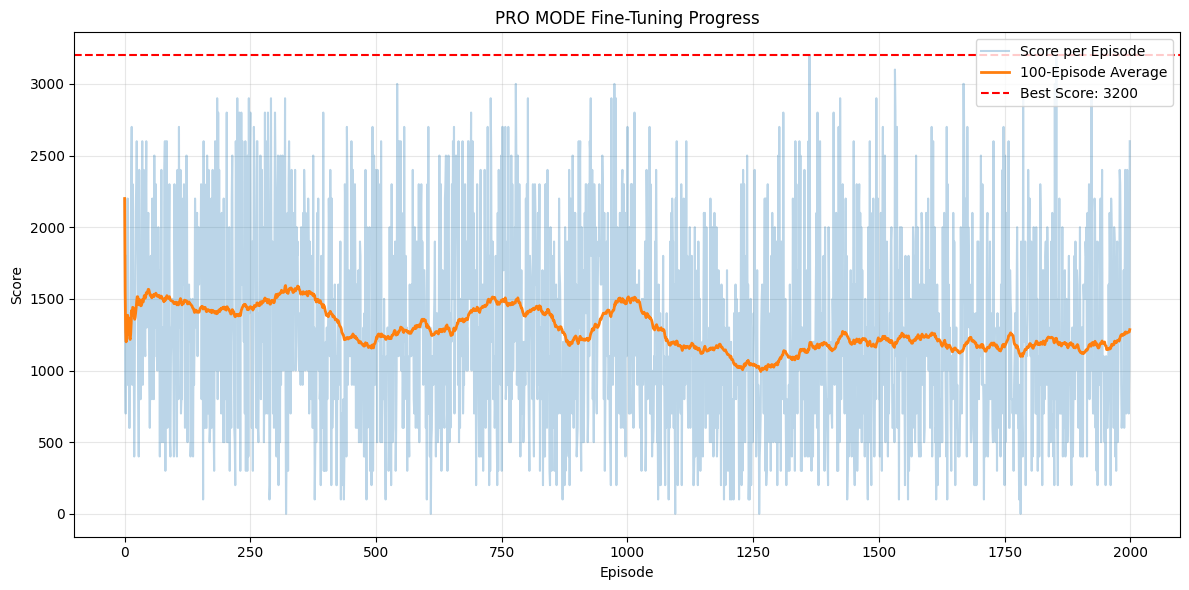

📊 Plot saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_promode_v3_20260117_030936/finetune_progress.png


In [ ]:
# ============================================================
# 📊 PLOT FINE-TUNING PROGRESS
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(scores, alpha=0.3, label='Score per Episode')
ax.plot(avg_scores, linewidth=2, label='100-Episode Average')
ax.axhline(y=best_score, color='r', linestyle='--', label=f'Best Score: {best_score}')
ax.set_xlabel('Episode')
ax.set_ylabel('Score')
ax.set_title('PRO MODE Fine-Tuning Progress')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/finetune_progress.png", dpi=150)
plt.show()

print(f"📊 Plot saved: {OUTPUT_DIR}/finetune_progress.png")

---
# 🎬 Record Video of Fine-Tuned AI

In [ ]:
# ============================================================
# 🎬 RECORD VIDEO WITH BEST MODEL
# ============================================================

# Load best average model for recording
agent.policy_net.load_state_dict(torch.load(f"{OUTPUT_DIR}/models/best_avg_model.pth", map_location=agent.device))
agent.epsilon = 0  # No exploration during recording

video_path = record_gameplay(
    agent,
    output_path=f"{OUTPUT_DIR}/videos/promode_gameplay_3.mp4",
    num_games=10,
    fps=60,
    max_frames=1200000
)

print(f"\n🎬 Video ready: {video_path}")


🎬 Recording 10 games...
pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
  Game 1/10...
    Score: 700 | Kills: 7
  Game 2/10...
    Score: 700 | Kills: 7
  Game 3/10...
    Score: 1700 | Kills: 17
  Game 4/10...
    Score: 700 | Kills: 7
  Game 5/10...
    Score: 800 | Kills: 8
  Game 6/10...


---
# 📁 Summary of Saved Files

In [ ]:
# ============================================================
# 📁 LIST ALL SAVED FILES
# ============================================================

import os

print("=" * 60)
print("📁 ALL SAVED FILES")
print("=" * 60)
print(f"\nOutput directory: {OUTPUT_DIR}\n")

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        if size > 1024 * 1024:
            size_str = f"{size / (1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"{subindent}📄 {file} ({size_str})")

print("\n" + "=" * 60)
print("✅ Fine-tuning complete! Use best_avg_model.pth for your demo.")
print("=" * 60)

In [ ]:
from google.colab import runtime
runtime.unassign()
